In [19]:
import sys
sys.path.insert(0, '..')

import json, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%load_ext autoreload
%autoreload 2

ROOT = Path('..')
TIER_COLORS = {0: '#a8a8a8', 1: '#DD8452', 2: '#4C72B0', 3: '#C44E52'}
TIER_LABELS = {
    0: 'Trivial',
    1: 'Easy',
    2: 'Moderate',
    3: 'Hard',
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
def load_scan(directory):
    files = sorted(glob.glob(str(ROOT / directory / '*.json')))
    by_qid, paths = {}, {}
    for f in files:
        d = json.load(open(f))
        qid = int(d['question_id'])
        if qid not in by_qid or f > paths[qid]:
            by_qid[qid] = d
            paths[qid] = f
    return by_qid

gpqa_raw = load_scan('results/mas/gpqa_subset_scan')
hb_raw = load_scan('results/mas/hiddenbench_subset_scan')
print(f'GPQA: {len(gpqa_raw)} | HiddenBench: {len(hb_raw)}')

GPQA: 198 | HiddenBench: 65


In [21]:
def votes_at(rep, t):
    return [a['vote'] for a in rep['trajectory'][t]['phase_b']]

def count_flips(rep):
    traj = rep['trajectory']
    total = 0
    for ag in range(len(traj[0]['phase_b'])):
        for t in range(1, len(traj)):
            if traj[t - 1]['phase_b'][ag]['vote'] != traj[t]['phase_b'][ag]['vote']:
                total += 1
    return total

def question_stats(d):
    reps = d['repetitions']
    gt = d['ground_truth']
    T_max = d['T']
    rep_stats, final_majorities = [], []
    for rep in reps:
        T = len(rep['trajectory'])
        v0 = votes_at(rep, 0)
        v_final = votes_at(rep, T - 1)
        majority = max(set(v_final), key=v_final.count)
        final_majorities.append(majority)
        rep_stats.append({
            'initial_unanimous': len(set(v0)) == 1,
            'initial_correct': sum(v == gt for v in v0) / len(v0),
            'flips': count_flips(rep),
            'trajectory_len': T,
            'consensus_reached': len(set(v_final)) == 1,
            'system_correct': majority == gt,
            'never_converged': T == T_max and len(set(v_final)) > 1,
        })
    return {
        'qid': int(d['question_id']),
        'gt': gt,
        'n_reps': len(rep_stats),
        'initial_unanimous_rate': float(np.mean([r['initial_unanimous'] for r in rep_stats])),
        'mean_flips': float(np.mean([r['flips'] for r in rep_stats])),
        'mean_trajectory_len': float(np.mean([r['trajectory_len'] for r in rep_stats])),
        'consensus_reached_rate': float(np.mean([r['consensus_reached'] for r in rep_stats])),
        'initial_correct_rate': float(np.mean([r['initial_correct'] for r in rep_stats])),
        'final_correct_rate': float(np.mean([r['system_correct'] for r in rep_stats])),
        'outcome_variance': len(set(final_majorities)) > 1,
        'never_converged_rate': float(np.mean([r['never_converged'] for r in rep_stats])),
    }

def assign_tier(row):
    if row['initial_unanimous_rate'] == 1.0 and row['mean_flips'] == 0.0:
        return 0
    if row['mean_trajectory_len'] <= 4.0:
        return 1
    if not row['outcome_variance']:
        return 2
    return 3

In [22]:
gpqa_df = pd.DataFrame([question_stats(d) for d in gpqa_raw.values()])
gpqa_df['tier'] = gpqa_df.apply(assign_tier, axis=1)
gpqa_df = gpqa_df.sort_values('qid').reset_index(drop=True)

hb_df = pd.DataFrame([question_stats(d) for d in hb_raw.values()])
hb_df['tier'] = hb_df.apply(assign_tier, axis=1)
hb_df = hb_df.sort_values('qid').reset_index(drop=True)

for name, df in [('GPQA', gpqa_df), ('HiddenBench', hb_df)]:
    counts = df['tier'].value_counts().sort_index()
    total = len(df)
    print(f'\n{name} ({total} questions):')
    for t, n in counts.items():
        print(f'  Tier {t} ({TIER_LABELS[t]}): {n} ({100 * n / total:.1f}%)')


GPQA (198 questions):
  Tier 0 (Trivial): 44 (22.2%)
  Tier 1 (Easy): 34 (17.2%)
  Tier 2 (Moderate): 44 (22.2%)
  Tier 3 (Hard): 76 (38.4%)

HiddenBench (65 questions):
  Tier 0 (Trivial): 4 (6.2%)
  Tier 1 (Easy): 3 (4.6%)
  Tier 2 (Moderate): 17 (26.2%)
  Tier 3 (Hard): 41 (63.1%)


## Tier Distribution

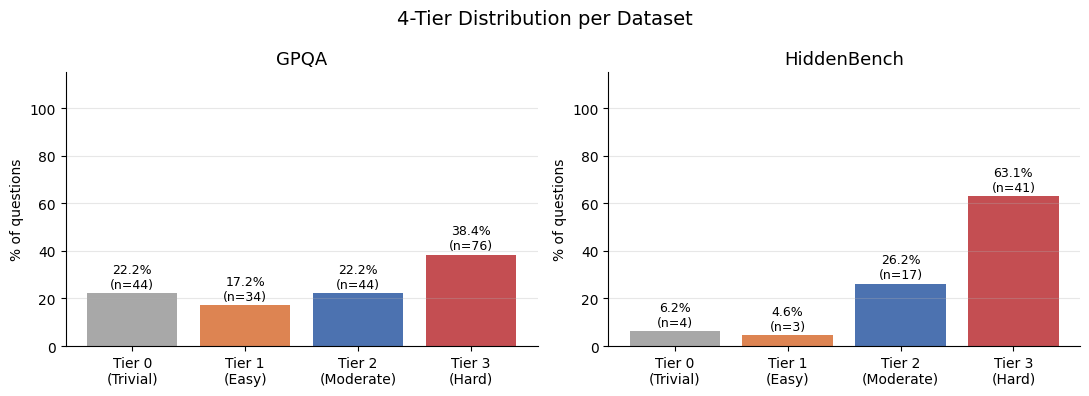

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, df) in zip(axes, [('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    counts = df['tier'].value_counts().sort_index()
    pcts = 100 * counts / len(df)
    bars = ax.bar(
        [f'Tier {t}\n({TIER_LABELS[t]})' for t in counts.index],
        pcts.values,
        color=[TIER_COLORS[t] for t in counts.index],
    )
    for bar, pct, n in zip(bars, pcts.values, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{pct:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=9)
    ax.set_title(name, fontsize=13)
    ax.set_ylabel('% of questions')
    ax.set_ylim(0, 115)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('4-Tier Distribution per Dataset', fontsize=14)
plt.tight_layout()
plt.show()

## Per-Tier Stats

In [24]:
def tier_summary(df):
    rows = []
    for tier in sorted(df['tier'].unique()):
        sub = df[df['tier'] == tier]
        rows.append({
            'tier': f'{tier} ({TIER_LABELS[tier]})',
            'n': len(sub),
            'pct_%': round(100 * len(sub) / len(df), 1),
            'init_unanimous': round(sub['initial_unanimous_rate'].mean(), 2),
            'mean_flips': round(sub['mean_flips'].mean(), 2),
            'mean_traj_len': round(sub['mean_trajectory_len'].mean(), 2),
            'consensus_rate': round(sub['consensus_reached_rate'].mean(), 2),
            'initial_acc': round(sub['initial_correct_rate'].mean(), 2),
            'final_acc': round(sub['final_correct_rate'].mean(), 2),
            'outcome_var_rate': round(float(sub['outcome_variance'].mean()), 2),
            'never_conv_rate': round(sub['never_converged_rate'].mean(), 2),
        })
    return pd.DataFrame(rows).set_index('tier')

print('GPQA')
display(tier_summary(gpqa_df))
print()
print('HiddenBench')
display(tier_summary(hb_df))

GPQA


,n,pct_%,init_unanimous,mean_flips,mean_traj_len,consensus_rate,initial_acc,final_acc,outcome_var_rate,never_conv_rate
tier,,,,,,,,,,
0 (Trivial),44,22.2,1.00,0.00,4.0,1.0,0.84,0.84,0.00,0.0
1 (Easy),34,17.2,0.45,0.76,4.0,1.0,0.59,0.69,0.21,0.0
2 (Moderate),44,22.2,0.20,2.95,5.2,1.0,0.45,0.59,0.00,0.0
3 (Hard),76,38.4,0.11,3.99,5.8,1.0,0.37,0.39,1.00,0.0



HiddenBench


,n,pct_%,init_unanimous,mean_flips,mean_traj_len,consensus_rate,initial_acc,final_acc,outcome_var_rate,never_conv_rate
tier,,,,,,,,,,
0 (Trivial),4,6.2,1.00,0.00,4.00,1.00,0.00,0.00,0.0,0.0
1 (Easy),3,4.6,0.33,0.67,4.00,1.00,0.11,0.00,0.0,0.0
2 (Moderate),17,26.2,0.14,4.14,7.41,0.88,0.22,0.35,0.0,0.0
3 (Hard),41,63.1,0.11,4.76,7.28,0.91,0.14,0.30,1.0,0.0


## Trajectory Length by Tier

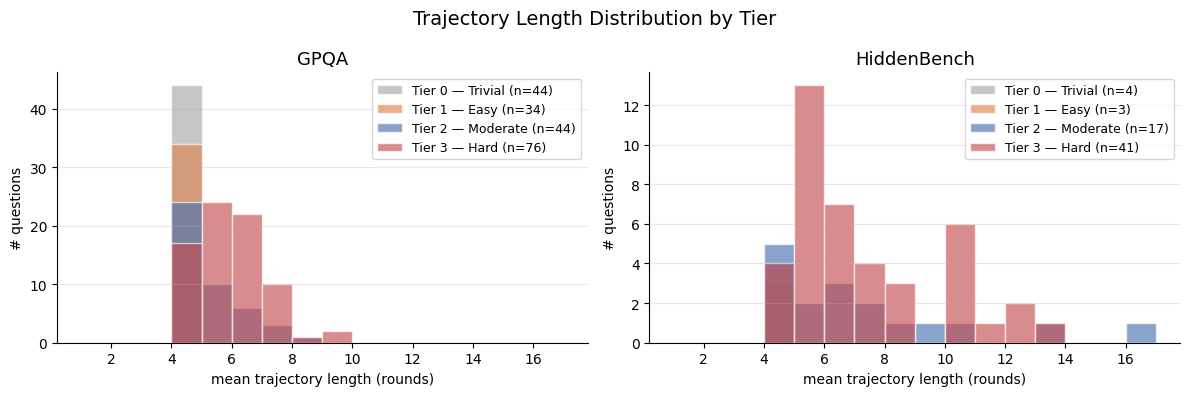

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    for tier in sorted(df['tier'].unique()):
        sub = df[df['tier'] == tier]['mean_trajectory_len']
        ax.hist(sub, bins=range(1, 18), alpha=0.65,
                color=TIER_COLORS[tier], label=f'Tier {tier} — {TIER_LABELS[tier]} (n={len(sub)})',
                edgecolor='white')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('mean trajectory length (rounds)')
    ax.set_ylabel('# questions')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Trajectory Length Distribution by Tier', fontsize=14)
plt.tight_layout()
plt.show()

## Accuracy: Round 0 vs Final by Tier

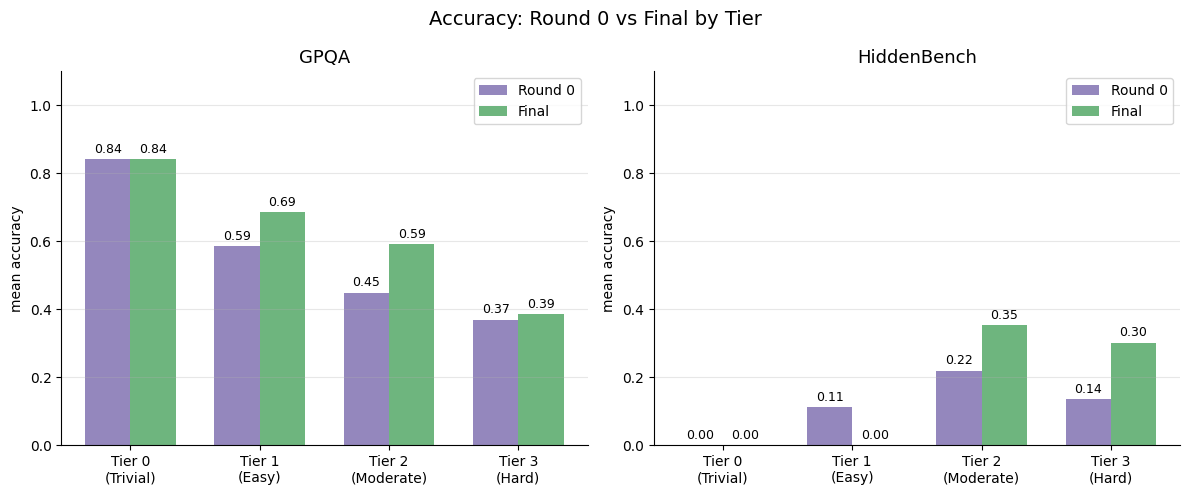

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, [('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    tiers = sorted(df['tier'].unique())
    x = np.arange(len(tiers))
    w = 0.35
    init_means = [df[df['tier'] == t]['initial_correct_rate'].mean() for t in tiers]
    final_means = [df[df['tier'] == t]['final_correct_rate'].mean() for t in tiers]
    ax.bar(x - w / 2, init_means, w, label='Round 0', color='#8172B2', alpha=0.85)
    ax.bar(x + w / 2, final_means, w, label='Final', color='#55A868', alpha=0.85)
    for xi, (iv, fv) in enumerate(zip(init_means, final_means)):
        ax.text(xi - w / 2, iv + 0.01, f'{iv:.2f}', ha='center', va='bottom', fontsize=9)
        ax.text(xi + w / 2, fv + 0.01, f'{fv:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Tier {t}\n({TIER_LABELS[t]})' for t in tiers])
    ax.set_ylabel('mean accuracy')
    ax.set_ylim(0, 1.1)
    ax.set_title(name, fontsize=13)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Accuracy: Round 0 vs Final by Tier', fontsize=14)
plt.tight_layout()
plt.show()

## Tier 2 vs Tier 3: Moderate vs Hard

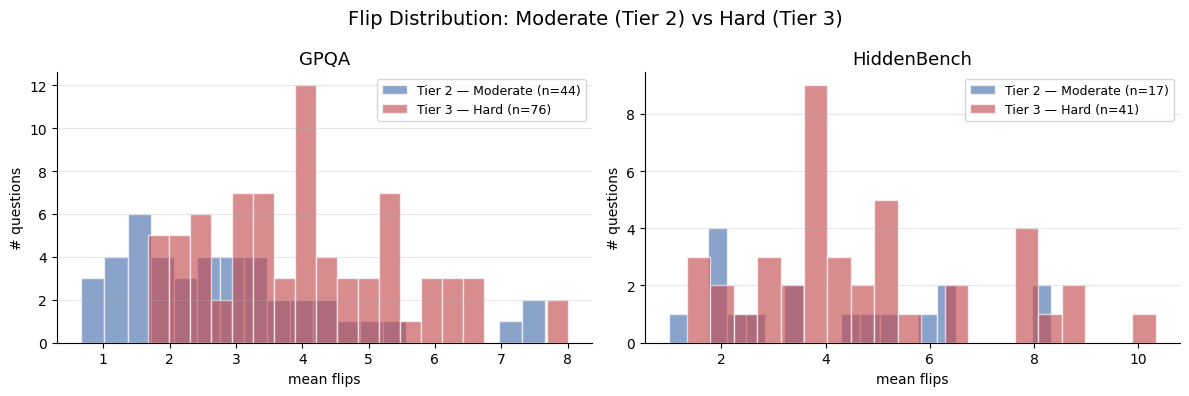

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [('GPQA', gpqa_df), ('HiddenBench', hb_df)]):
    for tier in [2, 3]:
        sub = df[df['tier'] == tier]
        if len(sub) == 0:
            continue
        ax.hist(sub['mean_flips'], bins=20, alpha=0.65,
                color=TIER_COLORS[tier], label=f'Tier {tier} — {TIER_LABELS[tier]} (n={len(sub)})',
                edgecolor='white')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('mean flips')
    ax.set_ylabel('# questions')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Flip Distribution: Moderate (Tier 2) vs Hard (Tier 3)', fontsize=14)
plt.tight_layout()
plt.show()

## Tier 3 Question IDs

In [28]:
gpqa_df_n4 = pd.DataFrame([question_stats(d) for d in gpqa_raw.values() if d['N'] == 4])
gpqa_df_n4['tier'] = gpqa_df_n4.apply(assign_tier, axis=1)

hb_df_n4 = pd.DataFrame([question_stats(d) for d in hb_raw.values() if d['N'] == 4])
hb_df_n4['tier'] = hb_df_n4.apply(assign_tier, axis=1)

gpqa_tiers = {
    str(t): sorted(gpqa_df_n4[gpqa_df_n4['tier'] == t]['qid'].tolist())
    for t in sorted(gpqa_df_n4['tier'].unique())
}
hb_tiers = {
    str(t): sorted(hb_df_n4[hb_df_n4['tier'] == t]['qid'].tolist())
    for t in sorted(hb_df_n4['tier'].unique())
}

subset_dir = ROOT / 'dataset'
(subset_dir / 'gpqa_tiers.json').write_text(json.dumps(gpqa_tiers, indent=2))
(subset_dir / 'hiddenbench_tiers.json').write_text(json.dumps(hb_tiers, indent=2))

for name, tiers in [('GPQA', gpqa_tiers), ('HiddenBench', hb_tiers)]:
    print(f'{name}:')
    for t, qids in tiers.items():
        print(f'  Tier {t}: {len(qids)} questions')
print('\nSaved gpqa_tiers.json and hiddenbench_tiers.json')

GPQA:
  Tier 0: 44 questions
  Tier 1: 34 questions
  Tier 2: 44 questions
  Tier 3: 76 questions
HiddenBench:
  Tier 0: 4 questions
  Tier 1: 3 questions
  Tier 2: 16 questions
  Tier 3: 35 questions

Saved gpqa_tiers.json and hiddenbench_tiers.json


## Visual Inspection — All Questions, All Tiers

In [29]:
def fmt_votes(votes):
    from collections import Counter
    c = Counter(votes)
    return '[' + ' '.join(f'{k}:{v}' for k, v in sorted(c.items())) + ']'

def inspect_all(raw, df, dataset_name):
    gt_map = {int(d['question_id']): d['ground_truth'] for d in raw.values()}
    tier_map = dict(zip(df['qid'], df['tier']))

    for tier in sorted(df['tier'].unique()):
        tier_qids = sorted(df[df['tier'] == tier]['qid'].tolist())
        print(f'\n{"=" * 70}')
        print(f'{dataset_name}  |  Tier {tier} — {TIER_LABELS[tier]}  ({len(tier_qids)} questions)')
        print(f'{"=" * 70}')

        for qid in tier_qids:
            d = raw[qid]
            gt = gt_map[qid]
            reps = d['repetitions']
            total_flips = np.mean([count_flips(r) for r in reps])
            mean_len = np.mean([len(r['trajectory']) for r in reps])
            ov = len({max(set(votes_at(r, len(r['trajectory']) - 1)),
                         key=votes_at(r, len(r['trajectory']) - 1).count)
                      for r in reps}) > 1

            print(f'\n  qid={qid}  gt={gt}  mean_rounds={mean_len:.1f}  mean_flips={total_flips:.1f}  outcome_var={ov}')
            for i, rep in enumerate(reps):
                traj = rep['trajectory']
                v0 = votes_at(rep, 0)
                vf = votes_at(rep, len(traj) - 1)
                majority = max(set(vf), key=vf.count)
                correct = '✓' if majority == gt else '✗'
                flips = count_flips(rep)
                rounds = len(traj)
                print(f'    rep {i:3d}: {correct} {majority}  '
                      f't0={fmt_votes(v0)} → tf={fmt_votes(vf)}  '
                      f'rounds={rounds}  flips={flips}')

print('GPQA')
inspect_all(gpqa_raw, gpqa_df, 'GPQA')
print()
print('HiddenBench')
inspect_all(hb_raw, hb_df, 'HiddenBench')

GPQA

GPQA  |  Tier 0 — Trivial  (44 questions)

  qid=0  gt=C  mean_rounds=4.0  mean_flips=0.0  outcome_var=False
    rep   0: ✓ C  t0=[C:4] → tf=[C:4]  rounds=4  flips=0
    rep   1: ✓ C  t0=[C:4] → tf=[C:4]  rounds=4  flips=0
    rep   2: ✓ C  t0=[C:4] → tf=[C:4]  rounds=4  flips=0

  qid=4  gt=B  mean_rounds=4.0  mean_flips=0.0  outcome_var=False
    rep   0: ✓ B  t0=[B:4] → tf=[B:4]  rounds=4  flips=0
    rep   1: ✓ B  t0=[B:4] → tf=[B:4]  rounds=4  flips=0
    rep   2: ✓ B  t0=[B:4] → tf=[B:4]  rounds=4  flips=0

  qid=16  gt=C  mean_rounds=4.0  mean_flips=0.0  outcome_var=False
    rep   0: ✓ C  t0=[C:4] → tf=[C:4]  rounds=4  flips=0
    rep   1: ✓ C  t0=[C:4] → tf=[C:4]  rounds=4  flips=0
    rep   2: ✓ C  t0=[C:4] → tf=[C:4]  rounds=4  flips=0

  qid=19  gt=A  mean_rounds=4.0  mean_flips=0.0  outcome_var=False
    rep   0: ✓ A  t0=[A:4] → tf=[A:4]  rounds=4  flips=0
    rep   1: ✓ A  t0=[A:4] → tf=[A:4]  rounds=4  flips=0
    rep   2: ✓ A  t0=[A:4] → tf=[A:4]  rounds=4  flips=

## Tier Distribution by Agent Count (N=3 vs N=4)

Saved ../plots/task_difficulty_4tiers_by_n.pdf


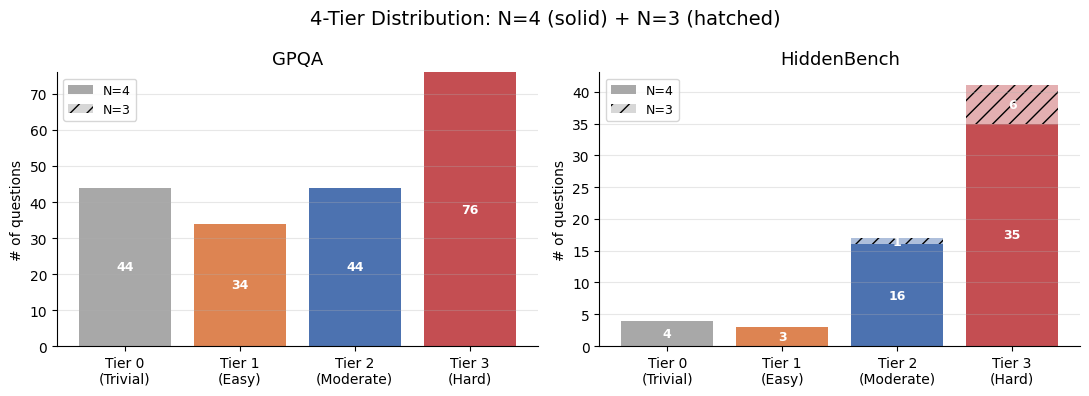

In [30]:
def build_df_by_n(raw, n_val):
    subset = {qid: d for qid, d in raw.items() if d['N'] == n_val}
    if not subset:
        return None
    df = pd.DataFrame([question_stats(d) for d in subset.values()])
    df['tier'] = df.apply(assign_tier, axis=1)
    return df.sort_values('qid').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, raw) in zip(axes, [('GPQA', gpqa_raw), ('HiddenBench', hb_raw)]):
    df4 = build_df_by_n(raw, 4)
    df3 = build_df_by_n(raw, 3)

    x_pos = np.arange(len(tiers := [0, 1, 2, 3]))
    counts4 = [len(df4[df4['tier'] == t]) if df4 is not None else 0 for t in tiers]
    counts3 = [len(df3[df3['tier'] == t]) if df3 is not None else 0 for t in tiers]

    bars4 = ax.bar(x_pos, counts4, color=[TIER_COLORS[t] for t in tiers], label='N=4')
    bars3 = ax.bar(x_pos, counts3, bottom=counts4, color=[TIER_COLORS[t] for t in tiers],
                   alpha=0.45, label='N=3', hatch='//')

    for xi, (n4, n3) in enumerate(zip(counts4, counts3)):
        if n4 > 0:
            ax.text(xi, n4 / 2, str(n4), ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
        if n3 > 0:
            ax.text(xi, n4 + n3 / 2, str(n3), ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'Tier {t}\n({TIER_LABELS[t]})' for t in tiers])
    ax.set_ylabel('# of questions')
    ax.set_title(name, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('4-Tier Distribution: N=4 (solid) + N=3 (hatched)', fontsize=14)
plt.tight_layout()

out_path = ROOT / 'plots' / 'task_difficulty_4tiers_by_n.pdf'
fig.savefig(out_path, bbox_inches='tight')
print(f'Saved {out_path}')
plt.show()